# Laboratorio 4, Parte 2, ejercicio 8 (interpretación y explicabilidad del modelo)

Este notebook carga el mejor modelo ya entrenado en `modelado_ml.ipynb` (guardado en `data/processed/modelos/estimadores/`) y lo explica: importancia global de variables, SHAP y dirección del efecto de las variables más influyentes, con interpretación ambiental. No reentrena ni revalida modelos, esos pasos ya están en las secciones 4 a 7 de `modelado_ml.ipynb`.

## 0. Preparación del entorno

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap


def localizar_proyecto(inicio=None):
    inicio = Path(inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if candidato.name == "l04_analisis_geoespacial" and (candidato / "data").exists():
            return candidato
        anidado = candidato / "l04_analisis_geoespacial"
        if (anidado / "data").exists():
            return anidado
    raise FileNotFoundError("No se encontró l04_analisis_geoespacial.")


PROJECT_DIR = localizar_proyecto()
SRC_DIR = PROJECT_DIR / "parte_2" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from modelar_ml import RANDOM_STATE, PREDICTORAS

OUTPUT_DIR = PROJECT_DIR / "parte_2" / "outputs"
SALIDA_MODELOS = PROJECT_DIR / "parte_2" / "data" / "processed" / "modelos"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

print(f"Proyecto: {PROJECT_DIR}")
print(f"Modelos guardados en: {SALIDA_MODELOS / 'estimadores'}")


Proyecto: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\l04_analisis_geoespacial
Modelos guardados en: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\l04_analisis_geoespacial\parte_2\data\processed\modelos\estimadores


# 8. Interpretación y explicabilidad del modelo

## 8.1 Tabla comparativa y selección del mejor modelo

Antes de explicar cualquier modelo, se compara el desempeño de los tres bajo las dos validaciones ya calculadas en `modelado_ml.ipynb`: la aleatoria (sección 5) y la espacial (sección 6, la más confiable según la discusión de 6.6, porque no deja fugar información entre píxeles vecinos).

In [2]:
metricas_aleatoria = pd.read_csv(SALIDA_MODELOS / "metricas_umbral_operativo.csv")
metricas_espacial = pd.read_csv(OUTPUT_DIR / "16_metricas_validacion_espacial_agregado.csv")

comp_aleatoria = metricas_aleatoria[["modelo", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc"]].copy()
comp_aleatoria["validacion"] = "Aleatoria (70/30)"

comp_espacial = metricas_espacial.rename(columns={
    "precision_mean": "precision", "recall_mean": "recall", "f1_mean": "f1",
    "f2_mean": "f2", "pr_auc_mean": "pr_auc", "roc_auc_mean": "roc_auc",
})[["modelo", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc"]].copy()
comp_espacial["validacion"] = "Espacial (media 5-fold)"

tabla_8_1 = pd.concat([comp_aleatoria, comp_espacial], ignore_index=True)
tabla_8_1 = tabla_8_1.sort_values(["modelo", "validacion"]).reset_index(drop=True)
formato = {c: "{:.4f}" for c in ["precision", "recall", "f1", "f2", "pr_auc", "roc_auc"]}
display(tabla_8_1.style.format(formato))
tabla_8_1.to_csv(OUTPUT_DIR / "21_tabla_comparativa_modelos.csv", index=False)

print("\nModelo elegido para interpretar: XGBoost")
print("Razón: mejor equilibrio bajo validación espacial (PR-AUC=0.901, recall=0.916),")
print("la más robusta de las dos validaciones; Random Forest gana solo en la aleatoria,")
print("la que la sección 6.6 ya identificó como optimista.")


,modelo,precision,recall,f1,f2,pr_auc,roc_auc,validacion
0,Random Forest,0.8044,0.9745,0.8813,0.9350,0.9667,0.9996,Aleatoria (70/30)
1,Random Forest,0.7574,0.8317,0.7919,0.8151,0.8722,0.9977,Espacial (media 5-fold)
2,Regresión Logística,0.6530,0.9203,0.7640,0.8507,0.8213,0.9978,Aleatoria (70/30)
3,Regresión Logística,0.6474,0.9111,0.7550,0.8407,0.8032,0.9973,Espacial (media 5-fold)
4,XGBoost,0.7626,0.9767,0.8565,0.9248,0.9592,0.9996,Aleatoria (70/30)
5,XGBoost,0.7449,0.9164,0.8214,0.8758,0.9011,0.9988,Espacial (media 5-fold)



Modelo elegido para interpretar: XGBoost
Razón: mejor equilibrio bajo validación espacial (PR-AUC=0.901, recall=0.916),
la más robusta de las dos validaciones; Random Forest gana solo en la aleatoria,
la que la sección 6.6 ya identificó como optimista.


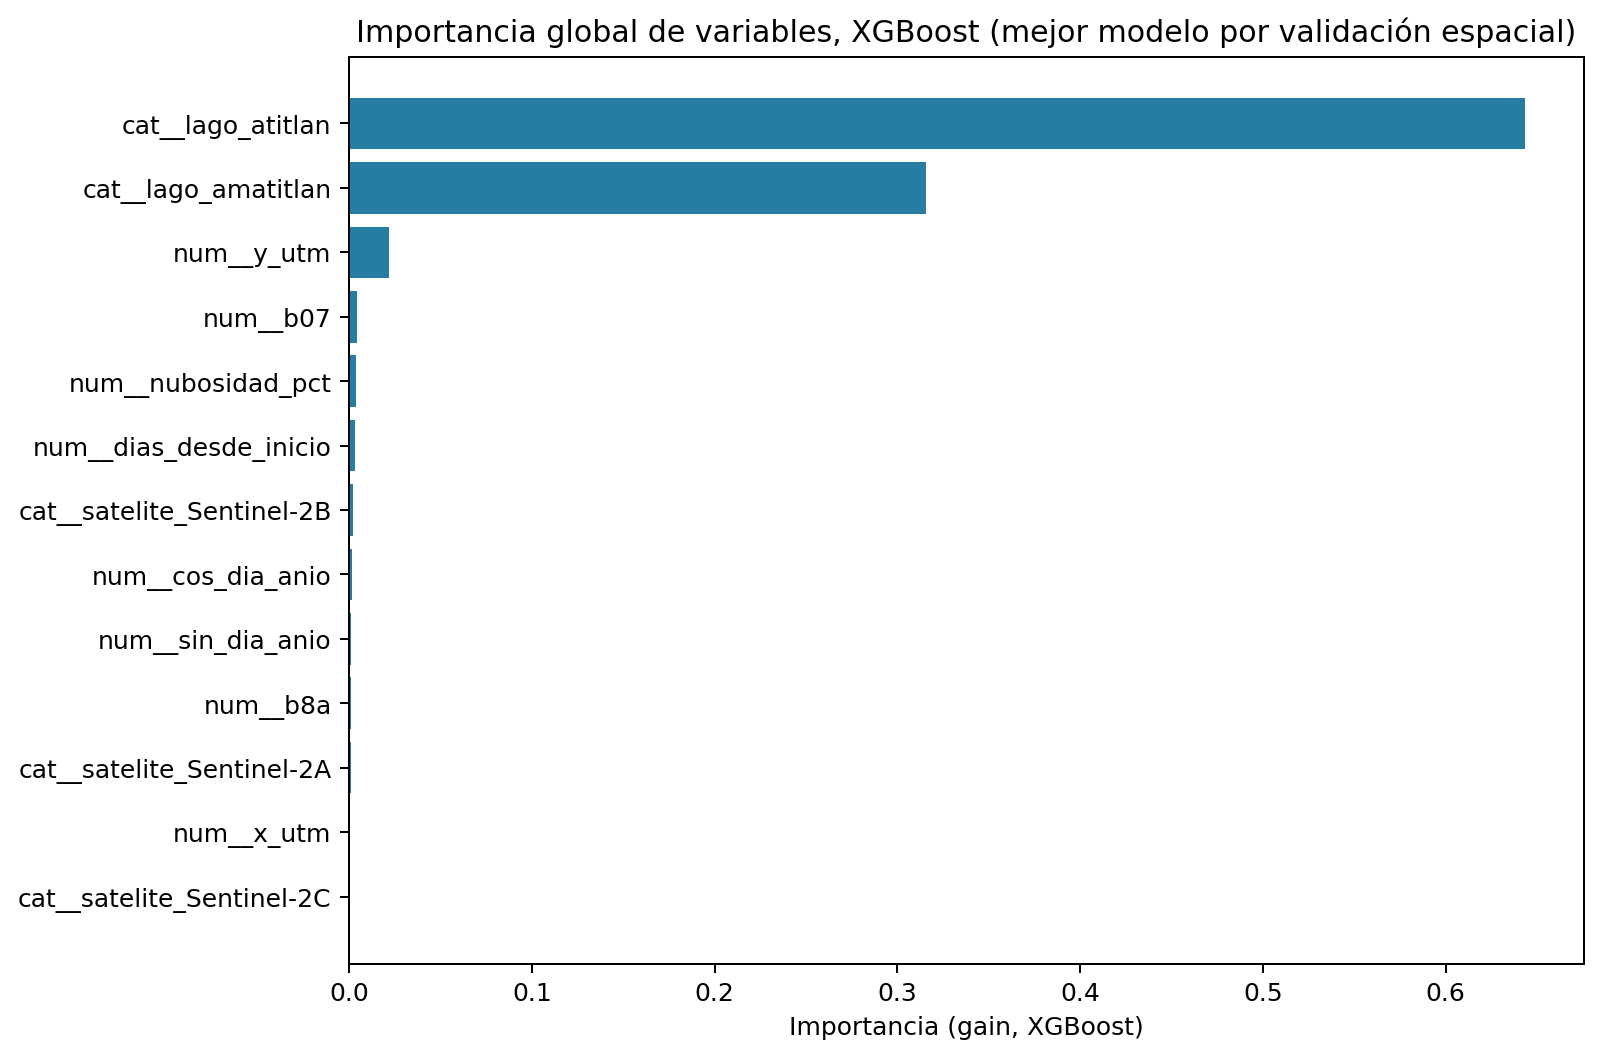

In [3]:
pipe = joblib.load(SALIDA_MODELOS / "estimadores" / "xgboost.joblib")
preprocesador = pipe.named_steps["pre"]
modelo_xgb = pipe.named_steps["modelo"]
nombres_columnas = list(preprocesador.get_feature_names_out())

importancias = pd.DataFrame({
    "variable": nombres_columnas,
    "importancia_gain": modelo_xgb.feature_importances_,
}).sort_values("importancia_gain", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importancias["variable"], importancias["importancia_gain"], color="#277DA1")
ax.set_xlabel("Importancia (gain, XGBoost)")
ax.set_title("Importancia global de variables, XGBoost (mejor modelo por validación espacial)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "23_importancia_global_xgboost.png", dpi=180, bbox_inches="tight")
plt.show()

importancias.to_csv(OUTPUT_DIR / "22_importancia_global_xgboost.csv", index=False)


**Interpretación.** La importancia nativa de XGBoost (`gain`, la reducción promedio de pérdida en los splits que usan esa variable) está dominada casi por completo por `cat__lago_atitlan` y `cat__lago_amatitlan` (0.65 y 0.32), muy por encima de `b07` o cualquier otra variable continua. Esto no significa que la ubicación sea "lo más importante" en un sentido intuitivo: `gain` favorece variables que producen unos pocos splits con enorme reducción de pérdida (como separar de raíz Atitlán de Amatitlán, dos poblaciones con prevalencias ~350 veces distintas), aunque esa variable se use en pocos nodos del árbol. Por eso en 8.2 se complementa con SHAP, que sí pondera el efecto real acumulado sobre cada predicción individual y da una imagen distinta y más matizada.

## 8.2 SHAP Summary Plot

A diferencia de `gain`, SHAP reparte de forma aditiva y consistente la contribución de cada variable a cada predicción individual, y el *summary plot* muestra, para una muestra del conjunto de prueba, tanto la magnitud como la dirección del efecto (color = valor de la variable, posición horizontal = impacto en la predicción).

Muestra usada para SHAP: (4000, 13)


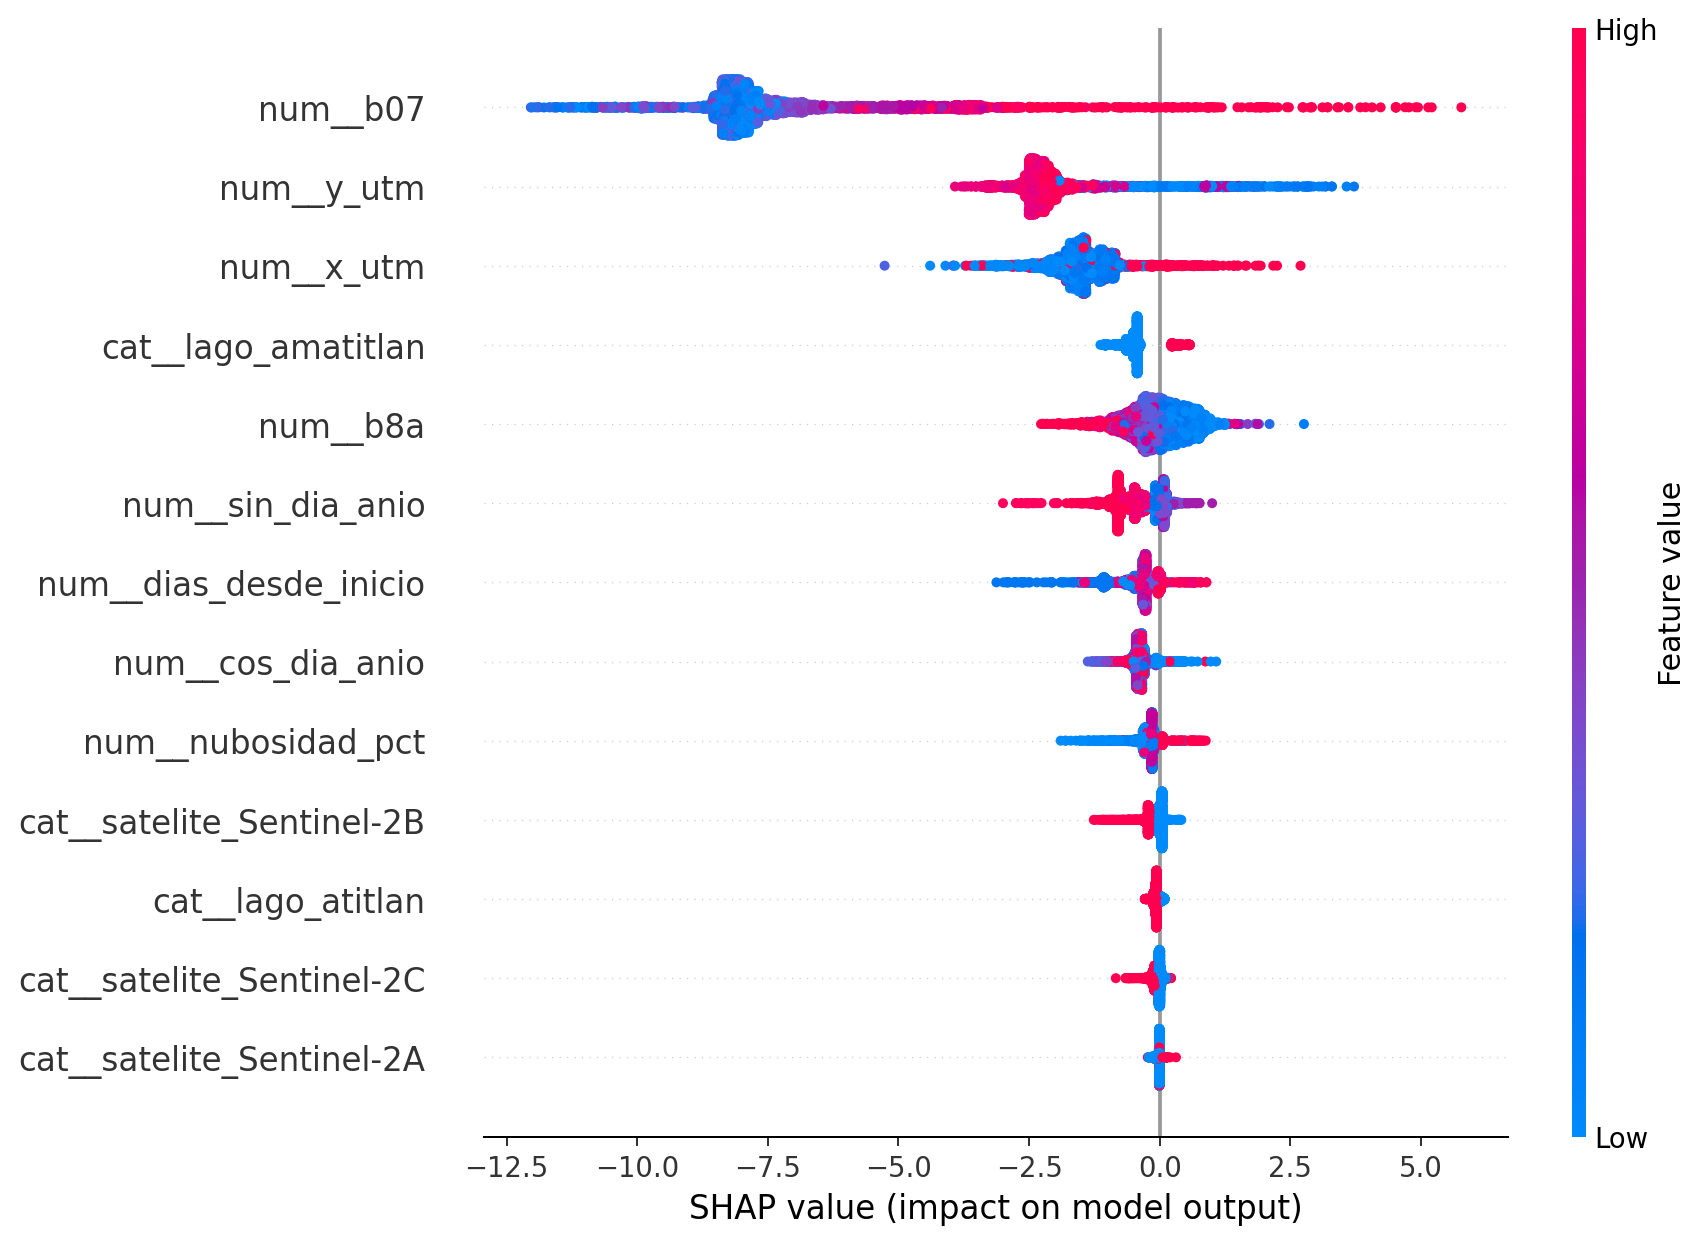

In [4]:
muestra = pd.read_parquet(SALIDA_MODELOS / "muestra_modelado.parquet")
test = muestra.loc[muestra["particion"] == "test"]
X_test = test[PREDICTORAS]

N_MUESTRA_SHAP = 4000
muestra_shap = X_test.sample(n=min(N_MUESTRA_SHAP, len(X_test)), random_state=RANDOM_STATE)
X_shap_transformado = preprocesador.transform(muestra_shap)
X_shap_df = pd.DataFrame(X_shap_transformado, columns=nombres_columnas, index=muestra_shap.index)

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_shap_df)
print("Muestra usada para SHAP:", X_shap_df.shape)

shap.summary_plot(shap_values, X_shap_df, show=False)
fig_summary = plt.gcf()
fig_summary.set_size_inches(10, 7)
plt.tight_layout()
fig_summary.savefig(OUTPUT_DIR / "24_shap_summary_plot.png", dpi=180, bbox_inches="tight")
plt.show()


**Interpretación.** Bajo SHAP el orden cambia por completo respecto a `gain`: **`b07` domina claramente** (el rango de impacto llega hasta ±12, muy por encima de todo lo demás), seguida de las coordenadas `y_utm` y `x_utm`, y solo después `lago_amatitlan`. El patrón de color es consistente en `b07`: puntos azules (reflectancia baja) caen del lado negativo (empujan hacia "baja presencia"), puntos rojos (reflectancia alta) caen del lado positivo. `b8a`, pese a ser el segundo predictor espectral, aparece con impacto mucho menor: al estar tan correlacionada con `b07` (ρ≈0.97, ya visto en la sección 1.5), el árbol prefiere dividir usando `b07` casi siempre y `b8a` aporta poco adicional una vez que `b07` ya está en el modelo, un síntoma típico de variables redundantes en SHAP. Las variables temporales (`sin_dia_anio`, `dias_desde_inicio`, `cos_dia_anio`) tienen impacto visible pero menor, y las variables de metadatos (satélite, `nubosidad_pct`) son las menos influyentes.

## 8.3 Variables más influyentes y dirección del efecto

Se ordenan las variables por la media de |SHAP| (magnitud de impacto promedio, sin cancelar signos) y se examina con *dependence plots* cómo cambia la predicción al aumentar o disminuir cada una de las tres más influyentes, esta es la prueba de sensibilidad "qué pasa si subo o bajo la variable", hecha con lo ya calculado en 8.2.

,variable,media_abs_shap
0,num__b07,7.194880
1,num__y_utm,2.126707
2,num__x_utm,1.495817
3,cat__lago_amatitlan,0.498005
4,num__b8a,0.445815
5,num__sin_dia_anio,0.437195
6,num__dias_desde_inicio,0.415317
7,num__cos_dia_anio,0.389100
8,num__nubosidad_pct,0.225855
9,cat__satelite_Sentinel-2B,0.130362


Top 3 variables por |SHAP| medio: ['num__b07', 'num__y_utm', 'num__x_utm']


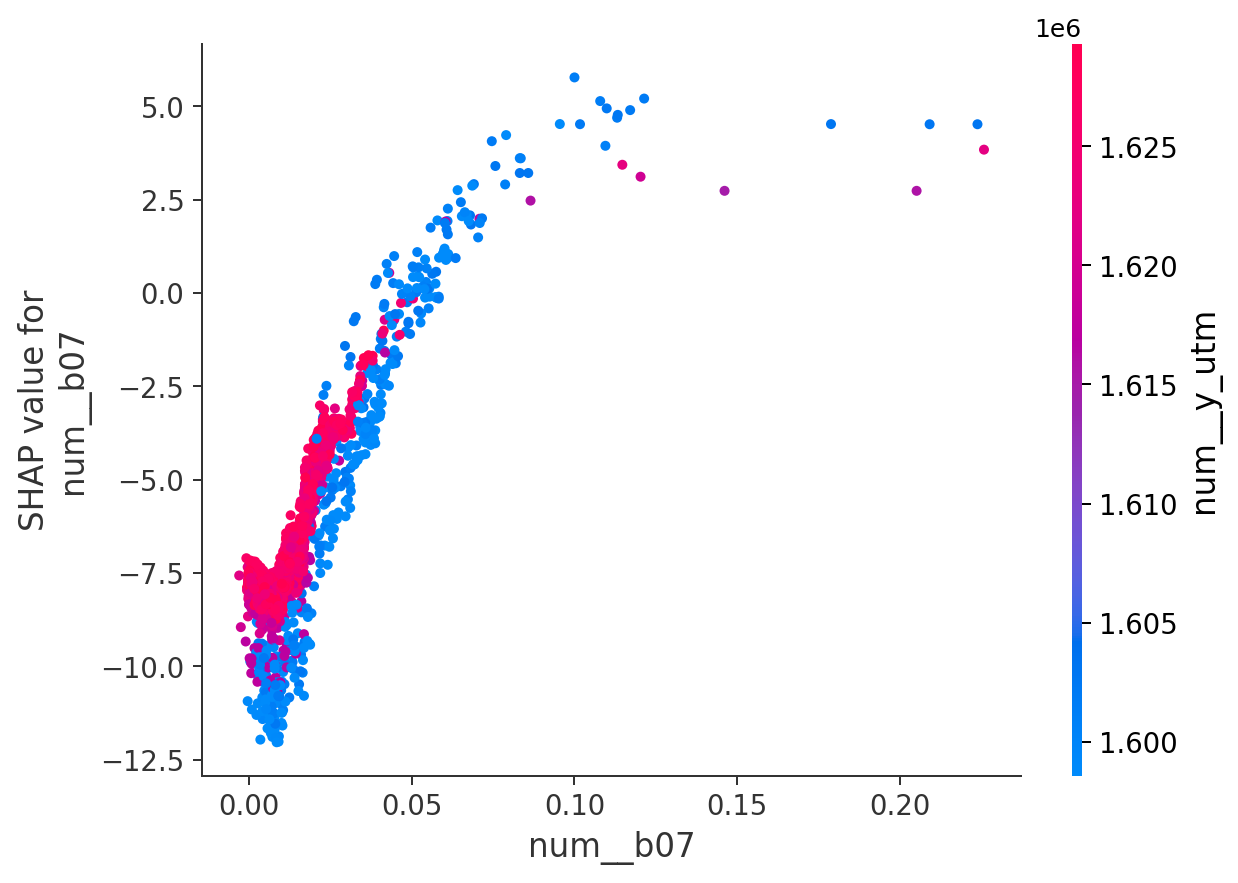

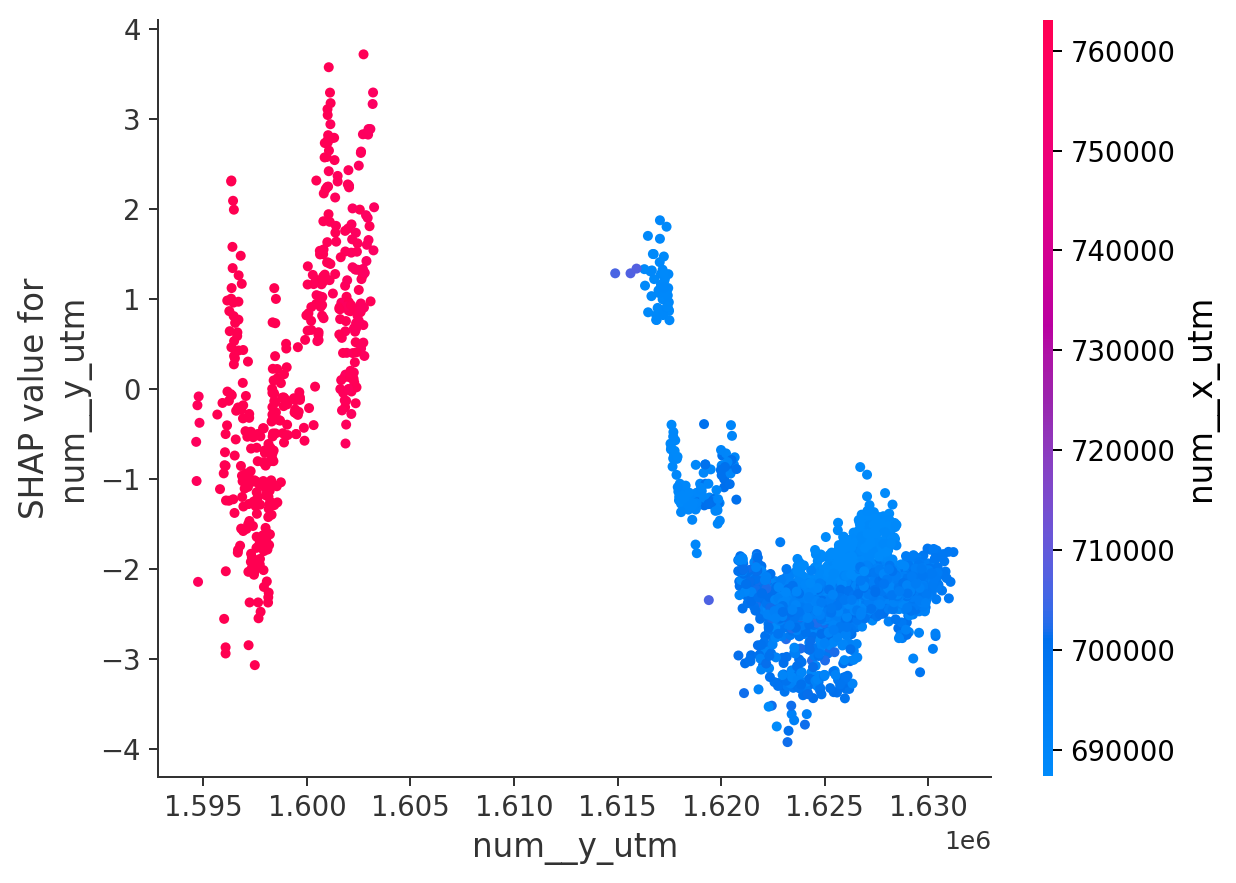

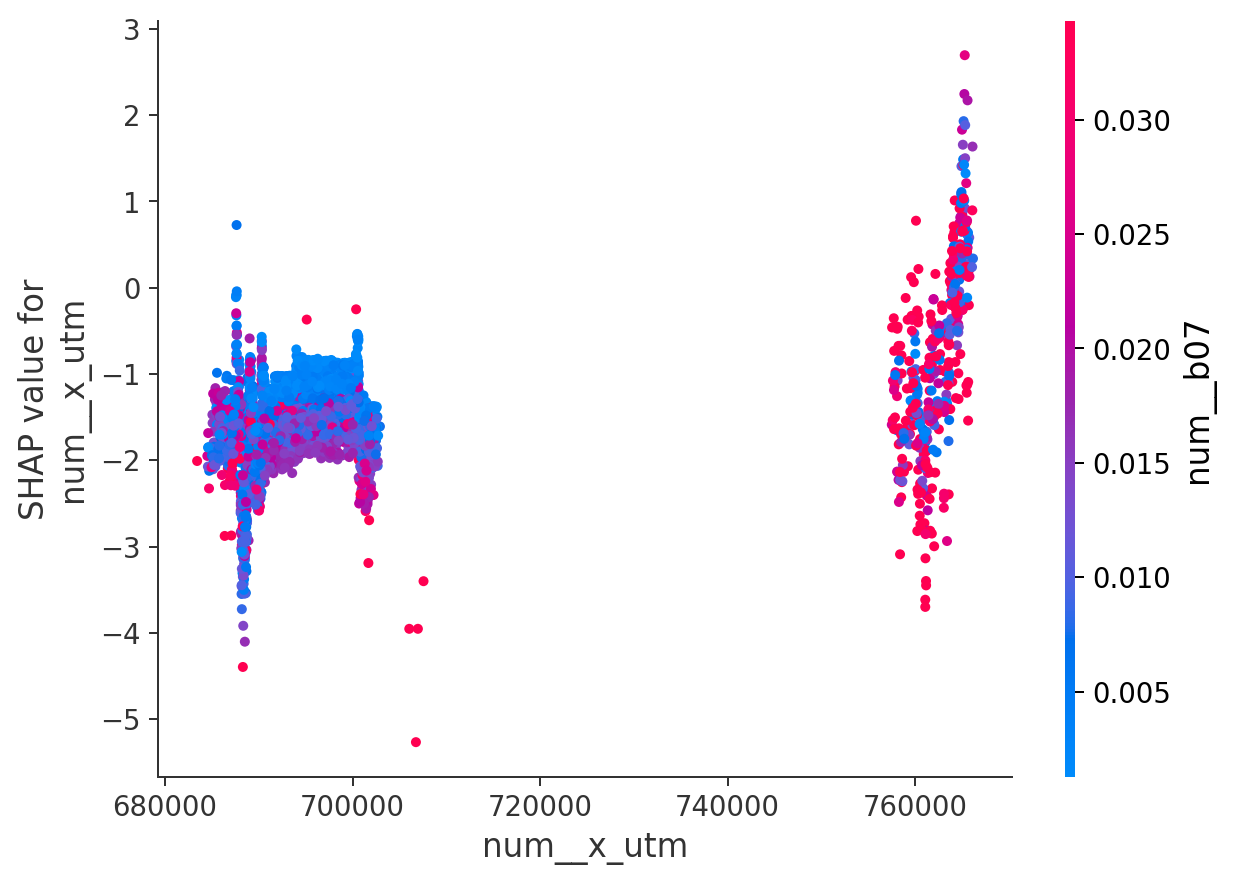

In [5]:
importancia_shap_media = pd.DataFrame({
    "variable": nombres_columnas,
    "media_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("media_abs_shap", ascending=False).reset_index(drop=True)
display(importancia_shap_media)
importancia_shap_media.to_csv(OUTPUT_DIR / "25_importancia_shap_media.csv", index=False)

top_variables = importancia_shap_media["variable"].head(3).tolist()
print("Top 3 variables por |SHAP| medio:", top_variables)

for i, var in enumerate(top_variables, start=1):
    plt.figure()
    shap.dependence_plot(var, shap_values, X_shap_df, show=False)
    fig_dep = plt.gcf()
    fig_dep.set_size_inches(7, 5)
    plt.tight_layout()
    fig_dep.savefig(OUTPUT_DIR / f"26_shap_dependence_{i}_{var.replace('__', '_')}.png", dpi=180, bbox_inches="tight")
    plt.show()


**Interpretación de cada variable:**

**`b07` (reflectancia red-edge, ~783 nm).** La relación es monótona y fuertemente no lineal, en forma de "S" que satura: el SHAP sube muy rápido de -12 a +5 mientras `b07` pasa de 0 a ~0.10-0.15, y luego se aplana, reflectancias por encima de ~0.15 ya no aumentan mucho más la predicción, porque esos píxeles ya son inequívocamente positivos. Ambientalmente: a mayor reflectancia en esta banda, mayor dispersión de luz por biomasa algal en el agua, y el modelo lo traduce directamente en mayor probabilidad de presencia elevada. Los puntos azules (menor `y_utm`, es decir Amatitlán) tienden a un SHAP levemente mayor que los rojos (Atitlán) para el mismo nivel de `b07`, sugiriendo una pequeña interacción: el modelo es algo más "generoso" interpretando reflectancia alta en Amatitlán, coherente con que ahí la floración ya es más frecuente.

**`y_utm` y `x_utm` (coordenadas).** El gráfico muestra dos nubes de puntos totalmente separadas, una por lago (las coordenadas de Atitlán y Amatitlán no se solapan). Dentro del grupo de Atitlán (`y_utm` alto, `x_utm` bajo) el SHAP es consistentemente negativo (entre -4 y 0): estar geográficamente en Atitlán empuja la predicción hacia abajo, coherente con su prevalencia real de apenas 0.03% (secciones 2.4 y 7). Dentro del grupo de Amatitlán (`y_utm` bajo, `x_utm` alto) el SHAP es mucho más disperso, entre -3 y +3.7: el modelo no trata a Amatitlán como uniformemente "de riesgo", sino que distingue zonas dentro del propio lago, probablemente asociadas a las áreas donde la floración ya está más establecida (consistente con los mapas de bloques de la sección 6.2, donde unos pocos bloques de Amatitlán concentran la mayoría de los positivos).

## 8.4 Discusión integradora

Los tres pasos de esta sección cuentan una historia coherente, no gráficas aisladas. La importancia nativa (`gain`) y SHAP no se contradicen, miden cosas distintas: `gain` resalta que la separación **entre lagos** es la división más "barata" en reducción de error (unos pocos splits explican mucho), mientras que SHAP revela que, **una vez fijado el lago**, la señal que realmente mueve la predicción de un píxel a otro es principalmente **espectral** (`b07`) y, en segundo lugar, la **posición dentro del lago** (coordenadas), es decir, el modelo primero "sabe dónde está" y después "mide cuánta biomasa hay ahí".

Esto es ambientalmente sensato y a la vez es una señal de alerta ya discutida en la sección 7: el modelo se apoya en gran medida en la identidad del lago y en la posición geográfica, exactamente los "atajos" que la sección 7 mostró que **no generalizan** a un lago nunca visto. La fuerte dependencia de `b07` es la parte más alentadora del resultado, porque es la única señal verdaderamente física y transferible entre lagos (refleja biomasa, no ubicación); la fuerte dependencia de las coordenadas es la parte más frágil, porque es exactamente lo que falla cuando se aplica el modelo a un lago distinto (sección 7.1-7.2) o a una zona espacialmente nueva (sección 6). En conjunto, estos resultados sugieren que un modelo verdaderamente generalizable debería apoyarse más en `b07`/`b8a` (y quizá en más bandas espectrales) y menos en la posición absoluta, algo que ya se exploró parcialmente al retirar `lago` y las coordenadas en la sección 7 y que podría ser el punto de partida de una futura iteración del modelo.